In [5]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms 

import matplotlib.pyplot as plt
import numpy as np
from typing import List
from pathlib import Path
import os
import nbformat

from model.image_dataset import ImageDataset
from model.classification import ClassificationType
from src.data_manager import DataManager

In [2]:
# (mean, std) = DataManager.calculate_mean_std()
# print(f"mean = {mean}")
# print(f"std = {std}")
# 
# mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
# std = [0.3104351758956909, 0.2893591821193695, 0.2897149622440338]

mean = [0.5008378028869629, 0.4241877496242523, 0.38265910744667053]
std = [0.3104351758956909, 0.2893591821193695, 0.2897149622440338]


In [ ]:
BATCH_SIZE = 32

current_dir = os.getcwd()
parent_dir = os.path.dirname(current_dir)
data_dir = os.path.join(parent_dir, "data", "processed")

# SPLIT 1

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
])
train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SPLIT 2

In [4]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.3104351758956909, 0.2893591821193695, 0.2897149622440338]
transform = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))
val_path = Path(os.path.join(data_dir, "val"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)
val_dataset = ImageDataset(val_path, transform)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# SPLIT 3

In [ ]:
mean = [0.5099310278892517, 0.4330956041812897, 0.3907594382762909]
std = [0.3104351758956909, 0.2893591821193695, 0.2897149622440338]
transform = transforms.Compose([
    transforms.Resize(size=(128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=mean,
        std=std
    )
])

train_path = Path(os.path.join(data_dir, "train"))
test_path = Path(os.path.join(data_dir, "test"))

train_dataset = ImageDataset(train_path, transform)
test_dataset = ImageDataset(test_path, transform)

val_size = int(0.2 * len(train_dataset))
train_indices = np.arange(len(train_dataset))
val_indices = np.random.choice(train_indices, size=val_size, replace=False)

val_dataset = Subset(train_dataset, val_indices)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [31]:
print(len(train_dataset))
print(len(test_dataset))
print(len(val_dataset))
# 174144

174140
21880
24477


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6426328..1.9269291].


tensor(2)


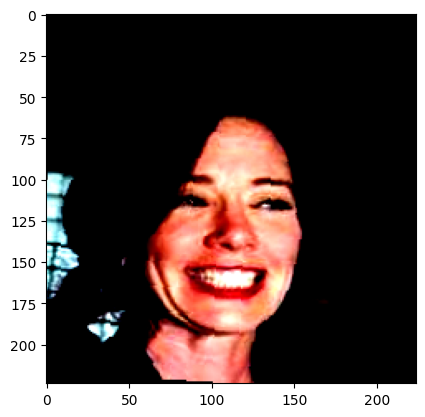

In [22]:
for images, labeles in train_loader:
    image = images[0].permute(1, 2, 0).numpy()
    plt.imshow(image)
    print(labeles[0])
    break